In [2]:
from utils import *

In [3]:
from scipy.io import loadmat

data = loadmat('PiecewiseSparse.mat')

print(data.keys())

for key in data:
    if not key.startswith('__'):
        print(key, type(data[key]), data[key].shape)

FinalState = data['FinalState']

print(FinalState[:5])

dict_keys(['__header__', '__version__', '__globals__', 'A', 'FinalState'])
A <class 'numpy.ndarray'> (25, 25)
FinalState <class 'numpy.ndarray'> (1000, 25)
[[ 0.4857785  -0.16707312  1.04447695 -1.53128619 -1.30124239 -2.35081066
  -2.90408382 -1.55804548  1.41306995  1.4198846  -1.2079779  -0.33041122
  -0.57360752  1.46539915 -0.91380475 -0.61622934 -0.96793198  0.69071141
   1.25369446  1.12781743 -0.85057941 -1.52988385 -2.21163324  0.02051388
   0.63577299]
 [ 0.8043342  -2.32208124  0.17925079  0.99974801 -0.3849271   0.71413997
  -1.43193474 -0.05905956 -1.54745501 -0.45974492  0.58317048  1.53397271
   1.60171094  0.07487441  0.16124308 -0.09490212  2.26448936 -2.19909791
  -0.55896492  3.9976778   0.40781636 -0.20628348  0.43991742  1.20147322
  -2.3951323 ]
 [ 0.08829475  0.59315931  0.12530907  0.60143333  0.14265209  0.01349492
  -0.65531139 -1.19494942 -0.66380116 -1.60193705  0.69821082  0.24706496
  -1.07112781  0.72390187 -0.12434298  1.04144769  0.1201882  -1.45833632


In [4]:
Xf = data['FinalState']

print("Shape:", Xf.shape)
print("Min:", Xf.min())
print("Max:", Xf.max())
print("Mean:", Xf.mean())
print("Std:", Xf.std())

Shape: (1000, 25)
Min: -4.232539423129264
Max: 3.9976778030754976
Mean: -0.0015596130427643358
Std: 1.0029575396312087


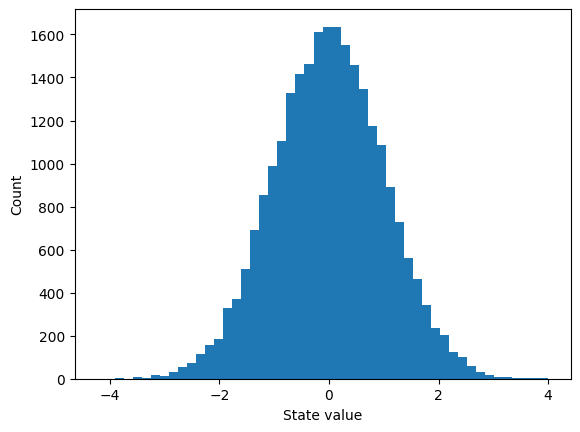

In [5]:
import matplotlib.pyplot as plt

plt.hist(Xf.flatten(), bins=50)
plt.xlabel("State value")
plt.ylabel("Count")
plt.show()

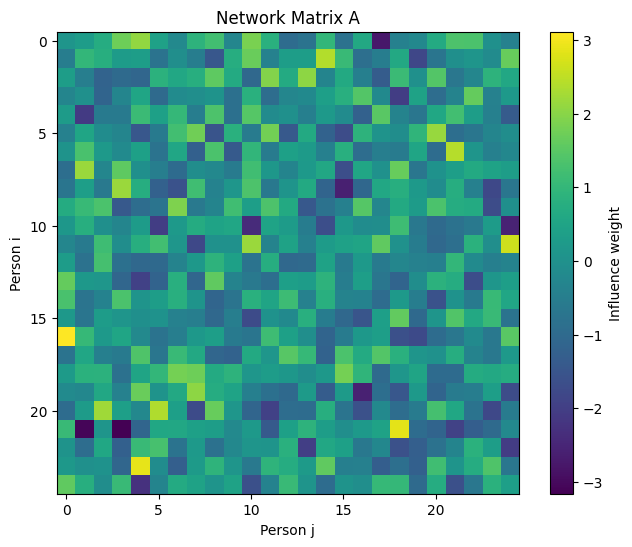

In [6]:
import matplotlib.pyplot as plt

A = data['A']

plt.figure(figsize=(8, 6))
plt.imshow(A)
plt.colorbar(label='Influence weight')
plt.xlabel('Person j')
plt.ylabel('Person i')
plt.title('Network Matrix A')

plt.show()

In [7]:
import numpy as np

print(np.count_nonzero(A))
print(np.linalg.eigvals(A))


625
[-5.72913784+2.02892111j -5.72913784-2.02892111j  4.49717782+2.00007119j
  4.49717782-2.00007119j  2.84992216+3.46973413j  2.84992216-3.46973413j
  4.35454464+0.j          3.79889705+0.44722518j  3.79889705-0.44722518j
 -2.73480019+2.96659534j -2.73480019-2.96659534j  0.54366496+3.56433773j
  0.54366496-3.56433773j -3.67216073+0.55268438j -3.67216073-0.55268438j
 -2.35744094+0.52922447j -2.35744094-0.52922447j -0.84485083+2.03502149j
 -0.84485083-2.03502149j  1.37330255+2.19406749j  1.37330255-2.19406749j
  0.77928477+1.59628308j  0.77928477-1.59628308j  0.91007179+0.j
 -0.67091681+0.j        ]


In [8]:
C = np.hstack([np.linalg.matrix_power(A, 24-k) for k in range(25)])

s = np.linalg.svd(C, compute_uv=False)

print("Largest singular value :", s[0])
print("Smallest singular value:", s[-1])
print("Condition number:", s[0]/s[-1])

Largest singular value : 1.117419684785262e+19
Smallest singular value: 141.49447624305637
Condition number: 7.89726718989214e+16


In [9]:
eigvals = np.linalg.eigvals(A)
print("spectral radius:", np.max(np.abs(eigvals)))

for k in [1, 5, 10, 15, 20, 24]:
    Ak = np.linalg.matrix_power(A, k)
    print(k, np.max(np.abs(Ak)))

spectral radius: 6.0777908165333985
1 3.1600595383474896
5 2737.0036436485457
10 22185579.447249033
15 173892833529.8953
20 1413630535430369.0
24 1.997236987192452e+18


## Controllability Checks

In [10]:
N = A.shape[0]

Ctrb = np.hstack([np.eye(N)] + [
    np.linalg.matrix_power(A, k)
    for k in range(1, N)
])

print("Ctrb shape:", Ctrb.shape)
print("rank Ctrb:", np.linalg.matrix_rank(Ctrb))
print("rank first 25 cols:", np.linalg.matrix_rank(Ctrb[:, :25]))

Ctrb shape: (25, 625)
rank Ctrb: 21
rank first 25 cols: 25


In [11]:
s = np.linalg.svd(Ctrb, compute_uv=False)

print("largest singular value =", s[0])
print("smallest singular value =", s[-1])
print("condition number =", s[0]/s[-1])

print(np.max(np.abs(Ctrb)))

largest singular value = 1.1174196847852622e+19
smallest singular value = 175.74950058915402
condition number = 6.358024808260657e+16
1.997236987192452e+18


In [12]:
import numpy as np

# -----------------------------
# Basic setup
# -----------------------------
N = A.shape[0]          # should be 25
T = N                   # horizon = N
x0 = np.zeros(N)

assert A.shape == (N, N)
assert Xf.shape[1] == N   # Xf is 1000 x 25


# -----------------------------
# Build controllability matrix
# C = [A^{T-1}, A^{T-2}, ..., A, I]
# -----------------------------
def build_C(A, T):
    N = A.shape[0]
    blocks = [np.linalg.matrix_power(A, T - 1 - k) for k in range(T)]
    return np.hstack(blocks)

C = build_C(A, T)

print("C shape:", C.shape)   # should be (25, 625)


# -----------------------------
# Coordinate change / column normalization
# C_tilde = C D^{-1}
# solve y = C_tilde z
# then u = D^{-1} z
# -----------------------------
col_norms = np.linalg.norm(C, axis=0)

# Avoid division by zero
eps = 1e-12
safe_col_norms = np.maximum(col_norms, eps)

C_tilde = C / safe_col_norms[None, :]

print("Original C column norms:")
print("min:", col_norms.min(), "max:", col_norms.max())

print("\nNormalized C_tilde column norms:")
print("min:", np.linalg.norm(C_tilde, axis=0).min())
print("max:", np.linalg.norm(C_tilde, axis=0).max())


# -----------------------------
# Since x0 = 0:
# y = xd - A^T x0 = xd
# Here xd is Xf[i]
# -----------------------------
Y = Xf.copy()   # shape: 1000 x 25


# -----------------------------
# Stability diagnostics
# -----------------------------
def diagnostics(M, name):
    svals = np.linalg.svd(M, compute_uv=False)
    rank_default = np.linalg.matrix_rank(M)
    cond = svals[0] / svals[-1]

    print(f"\n{name}")
    print("-" * len(name))
    print("shape:", M.shape)
    print("rank:", rank_default)
    print("largest singular value:", svals[0])
    print("smallest singular value:", svals[-1])
    print("condition number:", cond)

    return svals

s_C = diagnostics(C, "Original C")
s_Ctilde = diagnostics(C_tilde, "Column-normalized C_tilde")


# -----------------------------
# Least-squares sanity check
# Not sparse yet.
# This only checks whether the normalized coordinate system is consistent.
# -----------------------------
def ls_recovery_check(C, C_tilde, safe_col_norms, Y, num_tests=10):
    errors_original = []
    errors_normalized = []

    for i in range(num_tests):
        y = Y[i]

        # Direct least-squares on original system
        u_ls, *_ = np.linalg.lstsq(C, y, rcond=None)
        xhat_original = C @ u_ls
        err_original = np.linalg.norm(y - xhat_original) / np.linalg.norm(y)

        # Least-squares in normalized coordinates
        z_ls, *_ = np.linalg.lstsq(C_tilde, y, rcond=None)

        # Map back to original control coordinates
        u_from_z = z_ls / safe_col_norms

        xhat_normalized = C @ u_from_z
        err_normalized = np.linalg.norm(y - xhat_normalized) / np.linalg.norm(y)

        errors_original.append(err_original)
        errors_normalized.append(err_normalized)

    print("\nLeast-squares reconstruction sanity check")
    print("----------------------------------------")
    print("Original C mean relative error:", np.mean(errors_original))
    print("Normalized coordinate mean relative error:", np.mean(errors_normalized))
    print("Original C max relative error:", np.max(errors_original))
    print("Normalized coordinate max relative error:", np.max(errors_normalized))

ls_recovery_check(C, C_tilde, safe_col_norms, Y)


# -----------------------------
# Optional: check numerical rank under several tolerances
# -----------------------------
def rank_vs_tolerance(M, name):
    svals = np.linalg.svd(M, compute_uv=False)
    print(f"\nRank vs tolerance for {name}")
    print("-----------------------------")
    for tol in [1e-6, 1e-8, 1e-10, 1e-12, 1e-14]:
        rank = np.sum(svals > tol * svals[0])
        print(f"tol={tol:.0e}: rank={rank}")

rank_vs_tolerance(C, "Original C")
rank_vs_tolerance(C_tilde, "Column-normalized C_tilde")

C shape: (25, 625)
Original C column norms:
min: 1.0 max: 4.517338266030377e+18

Normalized C_tilde column norms:
min: 0.9999999999999997
max: 1.0000000000000002

Original C
----------
shape: (25, 625)
rank: 21
largest singular value: 1.117419684785262e+19
smallest singular value: 141.49447624305637
condition number: 7.89726718989214e+16

Column-normalized C_tilde
-------------------------
shape: (25, 625)
rank: 25
largest singular value: 16.701834441490455
smallest singular value: 1.0017891014191826
condition number: 16.672006530945318

Least-squares reconstruction sanity check
----------------------------------------
Original C mean relative error: 0.38820205544867326
Normalized coordinate mean relative error: 3.2388988367838575e-15
Original C max relative error: 0.6757882045306833
Normalized coordinate max relative error: 6.954611950803341e-15

Rank vs tolerance for Original C
-----------------------------
tol=1e-06: rank=15
tol=1e-08: rank=15
tol=1e-10: rank=18
tol=1e-12: rank=21
t

## OMP -- baseline

In [13]:
import numpy as np

def omp(Phi, y, K):
    """
    Standard Orthogonal Matching Pursuit

    Parameters
    ----------
    Phi : (m,n) ndarray
        Dictionary matrix (use C_tilde)
    y : (m,) ndarray
        Measurement vector
    K : int
        Total sparsity budget

    Returns
    -------
    z_hat : (n,) ndarray
        Recovered sparse coefficients
    support : list
        Selected atom indices
    residual_norms : list
        Residual norm history
    """

    m, n = Phi.shape

    residual = y.copy()
    support = []
    residual_norms = [np.linalg.norm(residual)]

    z_hat = np.zeros(n)

    for _ in range(K):

        # Correlations
        corr = Phi.T @ residual

        # Prevent reselection
        if support:
            corr[support] = 0

        idx = np.argmax(np.abs(corr))
        support.append(idx)

        # Restricted dictionary
        Phi_S = Phi[:, support]

        # Orthogonal projection
        z_S, *_ = np.linalg.lstsq(Phi_S, y, rcond=None)

        residual = y - Phi_S @ z_S

        residual_norms.append(np.linalg.norm(residual))

    z_hat[support] = z_S

    return z_hat, support, residual_norms

In [14]:
s = 2
K = 25 * s

i = 0

y = Xf[i]

z_hat, support, residuals = omp(C_tilde, y, K)

# Undo normalization
u_hat = z_hat / safe_col_norms

# Final state under original dynamics
xN_hat = C @ u_hat

error = np.linalg.norm(y - xN_hat) / np.linalg.norm(y)

print("K =", K)
print("Selected atoms =", len(support))
print("Relative error =", error)
print("Energy =", np.linalg.norm(u_hat))

K = 50
Selected atoms = 50
Relative error = 1.2993945456511123e-15
Energy = 5.7989649767879765


In [15]:
def evaluate_omp(Xf, C, C_tilde, safe_col_norms, s):

    K = 25 * s

    errors = []
    energies = []

    for i in range(len(Xf)):

        y = Xf[i]

        z_hat, _, _ = omp(C_tilde, y, K)

        u_hat = z_hat / safe_col_norms

        xN_hat = C @ u_hat

        err = np.linalg.norm(y - xN_hat) / np.linalg.norm(y)
        energy = np.linalg.norm(u_hat)

        errors.append(err)
        energies.append(energy)

    return np.array(errors), np.array(energies)

In [16]:
s_values = [1,2,3,4,5]

for s in s_values:

    errors, energies = evaluate_omp(
        Xf,
        C,
        C_tilde,
        safe_col_norms,
        s
    )

    print("\n-------------------")
    print(f"s = {s}")
    print("-------------------")
    print("Mean error :", errors.mean())
    print("Median error :", np.median(errors))
    print("Max error :", errors.max())
    print("Mean energy :", energies.mean())


-------------------
s = 1
-------------------
Mean error : 1.4264949534931928e-15
Median error : 1.1105910798147115e-15
Max error : 1.1700952846897371e-14
Mean energy : 4.35940022845141

-------------------
s = 2
-------------------
Mean error : 1.9372857772677202e-15
Median error : 1.5934049583477887e-15
Max error : 1.1472554353967066e-14
Mean energy : 3.621172484661528

-------------------
s = 3
-------------------
Mean error : 2.018476767007625e-15
Median error : 1.6567542760890741e-15
Max error : 1.4102465860387549e-14
Mean energy : 3.2671482691756446

-------------------
s = 4
-------------------
Mean error : 2.1176259851233167e-15
Median error : 1.7245932859247289e-15
Max error : 1.498863041523547e-14
Mean energy : 3.0709342471903516

-------------------
s = 5
-------------------
Mean error : 2.087585755564852e-15
Median error : 1.7511330663191714e-15
Max error : 1.2264503162787542e-14
Mean energy : 2.946712705998691


In [17]:
y = Xf[0]

for s in [1,2,3,4,5]:

    K = 25*s

    z_hat, _, _ = omp(C_tilde, y, K)

    u_hat = z_hat / safe_col_norms

    print(
        f"s={s:2d}, "
        f"||u||_0={np.count_nonzero(np.abs(u_hat)>1e-10):3d}"
    )

s= 1, ||u||_0= 25
s= 2, ||u||_0= 50
s= 3, ||u||_0= 75
s= 4, ||u||_0=100
s= 5, ||u||_0=124


In [18]:
def block_sparsity_profile(u_hat, N=25, T=25, threshold=1e-10):
    """
    Measures how nonzeros are distributed across time blocks.

    u_hat is stacked as:
        [u_0, u_1, ..., u_{T-1}]
    each u_k has length N.
    """

    U = u_hat.reshape(T, N)

    active = np.abs(U) > threshold

    block_counts = active.sum(axis=1)      # nonzeros per time block
    node_counts = active.sum(axis=0)       # nonzeros per person/node across time

    metrics = {
        "block_counts": block_counts,
        "node_counts": node_counts,

        "total_sparsity": block_counts.sum(),

        "avg_block_sparsity": block_counts.mean(),
        "max_block_sparsity": block_counts.max(),
        "min_block_sparsity": block_counts.min(),
        "std_block_sparsity": block_counts.std(),

        "num_active_blocks": np.sum(block_counts > 0),
        "fraction_active_blocks": np.mean(block_counts > 0),

        "avg_node_sparsity": node_counts.mean(),
        "max_node_sparsity": node_counts.max(),
        "num_active_nodes": np.sum(node_counts > 0),
        "fraction_active_nodes": np.mean(node_counts > 0),
    }

    return metrics

In [19]:
s = 2
K = 25 * s
y = Xf[0]

z_hat, support, residuals = omp(C_tilde, y, K)
u_hat = z_hat / safe_col_norms

metrics = block_sparsity_profile(u_hat, N=25, T=25)

for key, value in metrics.items():
    print(key, ":", value)

block_counts : [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  2  0  1  0  3  4  3  7 11
 19]
node_counts : [2 1 1 1 3 1 4 3 3 3 1 2 1 3 1 1 1 3 4 3 1 1 1 2 3]
total_sparsity : 50
avg_block_sparsity : 2.0
max_block_sparsity : 19
min_block_sparsity : 0
std_block_sparsity : 4.33589667773576
num_active_blocks : 8
fraction_active_blocks : 0.32
avg_node_sparsity : 2.0
max_node_sparsity : 4
num_active_nodes : 25
fraction_active_nodes : 1.0


In [20]:
def evaluate_omp_block_distribution(Xf, C_tilde, safe_col_norms, s, N=25, T=25):
    K = T * s

    all_block_counts = []
    all_node_counts = []

    total_sparsities = []
    avg_block_sparsities = []
    max_block_sparsities = []
    std_block_sparsities = []
    active_block_fractions = []

    avg_node_sparsities = []
    max_node_sparsities = []
    active_node_fractions = []

    for i in range(Xf.shape[0]):
        y = Xf[i]

        z_hat, _, _ = omp(C_tilde, y, K)
        u_hat = z_hat / safe_col_norms

        metrics = block_sparsity_profile(u_hat, N=N, T=T)

        all_block_counts.append(metrics["block_counts"])
        all_node_counts.append(metrics["node_counts"])

        total_sparsities.append(metrics["total_sparsity"])
        avg_block_sparsities.append(metrics["avg_block_sparsity"])
        max_block_sparsities.append(metrics["max_block_sparsity"])
        std_block_sparsities.append(metrics["std_block_sparsity"])
        active_block_fractions.append(metrics["fraction_active_blocks"])

        avg_node_sparsities.append(metrics["avg_node_sparsity"])
        max_node_sparsities.append(metrics["max_node_sparsity"])
        active_node_fractions.append(metrics["fraction_active_nodes"])

    return {
        "all_block_counts": np.array(all_block_counts),
        "all_node_counts": np.array(all_node_counts),

        "total_sparsity_mean": np.mean(total_sparsities),
        "avg_block_sparsity_mean": np.mean(avg_block_sparsities),
        "max_block_sparsity_mean": np.mean(max_block_sparsities),
        "std_block_sparsity_mean": np.mean(std_block_sparsities),
        "active_block_fraction_mean": np.mean(active_block_fractions),

        "avg_node_sparsity_mean": np.mean(avg_node_sparsities),
        "max_node_sparsity_mean": np.mean(max_node_sparsities),
        "active_node_fraction_mean": np.mean(active_node_fractions),
    }

In [21]:
for s in [1, 2, 3, 4, 5]:

    dist = evaluate_omp_block_distribution(
        Xf=Xf,
        C_tilde=C_tilde,
        safe_col_norms=safe_col_norms,
        s=s,
        N=25,
        T=25
    )

    print("\n----------------")
    print(f"s = {s}")
    print("----------------")
    print("Mean total sparsity:", dist["total_sparsity_mean"])
    print("Mean avg block sparsity:", dist["avg_block_sparsity_mean"])
    print("Mean max block sparsity:", dist["max_block_sparsity_mean"])
    print("Mean std block sparsity:", dist["std_block_sparsity_mean"])
    print("Mean active block fraction:", dist["active_block_fraction_mean"])
    print("Mean avg node sparsity:", dist["avg_node_sparsity_mean"])
    print("Mean max node sparsity:", dist["max_node_sparsity_mean"])
    print("Mean active node fraction:", dist["active_node_fraction_mean"])


----------------
s = 1
----------------
Mean total sparsity: 24.999
Mean avg block sparsity: 0.9999600000000001
Mean max block sparsity: 19.433
Mean std block sparsity: 3.842641168656097
Mean active block fraction: 0.15952000000000002
Mean avg node sparsity: 0.9999600000000001
Mean max node sparsity: 2.272
Mean active node fraction: 0.8276400000000002

----------------
s = 2
----------------
Mean total sparsity: 49.693
Mean avg block sparsity: 1.9877200000000002
Mean max block sparsity: 20.432
Mean std block sparsity: 4.457188603172555
Mean active block fraction: 0.35088
Mean avg node sparsity: 1.9877200000000002
Mean max node sparsity: 4.444
Mean active node fraction: 0.9466800000000001

----------------
s = 3
----------------
Mean total sparsity: 73.466
Mean avg block sparsity: 2.93864
Mean max block sparsity: 21.129
Mean std block sparsity: 5.334365802033
Mean active block fraction: 0.4156400000000001
Mean avg node sparsity: 2.93864
Mean max node sparsity: 5.995
Mean active node fr

In [22]:
import numpy as np
import matplotlib.pyplot as plt

def support_heatmap_omp(Xf, C_tilde, safe_col_norms, s, N=25, T=25, threshold=1e-10):
    K = T * s
    support_counts = np.zeros((T, N))

    for i in range(Xf.shape[0]):
        y = Xf[i]

        z_hat, support, _ = omp(C_tilde, y, K)

        u_hat = z_hat / safe_col_norms
        U = u_hat.reshape(T, N)

        support_mask = np.abs(U) > threshold
        support_counts += support_mask.astype(float)

    support_frequency = support_counts / Xf.shape[0]

    return support_counts, support_frequency

In [23]:
s = 2

support_counts, support_frequency = support_heatmap_omp(
    Xf=Xf,
    C_tilde=C_tilde,
    safe_col_norms=safe_col_norms,
    s=s,
    N=25,
    T=25
)

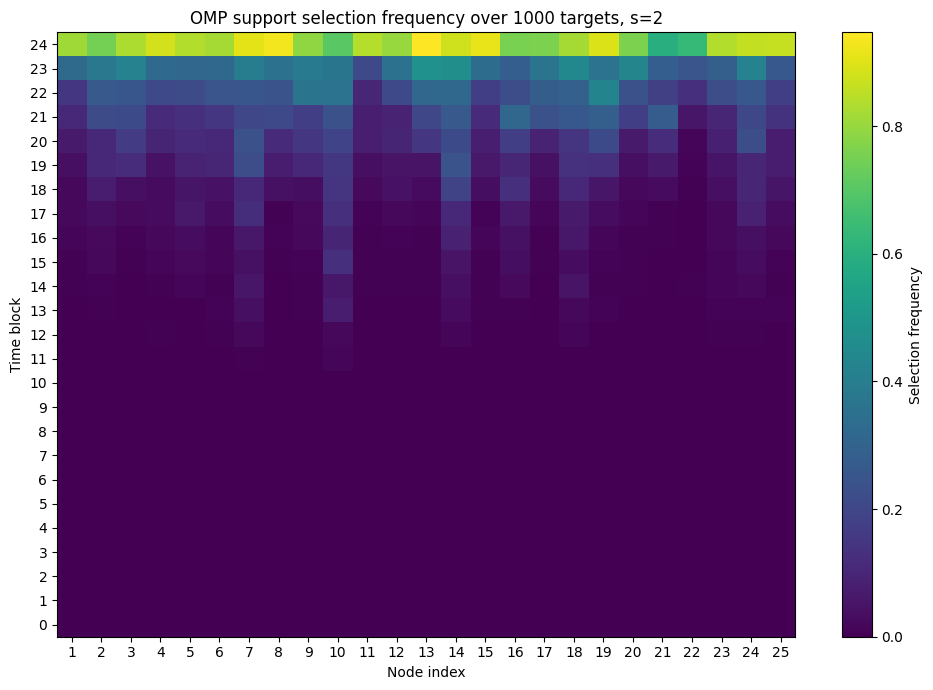

In [24]:
plt.figure(figsize=(10, 7))
plt.imshow(support_frequency, aspect="auto", origin="lower")
plt.colorbar(label="Selection frequency")

plt.xlabel("Node index")
plt.ylabel("Time block")
plt.title(f"OMP support selection frequency over 1000 targets, s={s}")

plt.xticks(np.arange(25), np.arange(1, 26))
plt.yticks(np.arange(25), np.arange(0, 25))

plt.tight_layout()
plt.show()

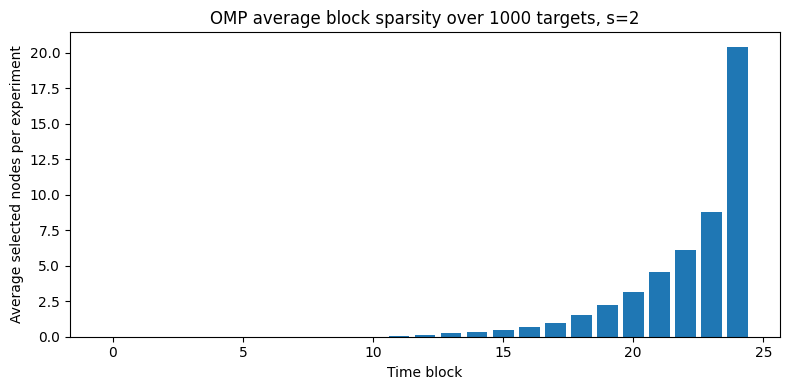

In [25]:
time_selection_frequency = support_frequency.sum(axis=1)

plt.figure(figsize=(8, 4))
plt.bar(np.arange(T), time_selection_frequency)

plt.xlabel("Time block")
plt.ylabel("Average selected nodes per experiment")
plt.title(f"OMP average block sparsity over 1000 targets, s={s}")

plt.tight_layout()
plt.show()

## P-OMP

In [27]:
import numpy as np

def top_k_abs_indices(v, k):
    """Return indices of k largest-magnitude entries of v."""
    if k <= 0:
        return np.array([], dtype=int)
    k = min(k, len(v))
    return np.argpartition(np.abs(v), -k)[-k:]


def piecewise_prune(z, s, N=25, T=25):
    """
    Keep at most s entries per time block.
    z is stacked as [z_0, z_1, ..., z_{T-1}], each block length N.
    """
    z_pruned = np.zeros_like(z)

    for t in range(T):
        start = t * N
        end = (t + 1) * N

        block = z[start:end]
        local_idx = top_k_abs_indices(block, s)

        z_pruned[start + local_idx] = block[local_idx]

    return z_pruned


def pomp(Phi, y, s, N=25, T=25, max_iter=None, tol=1e-12, ridge=0.0):
    """
    Piecewise Orthogonal Matching Pursuit.

    Solves approximately:
        y = Phi z

    with piecewise sparsity:
        each block z_t has at most s nonzeros.

    Parameters
    ----------
    Phi : ndarray, shape (m, N*T)
        Dictionary matrix. Use C_tilde.
    y : ndarray, shape (m,)
        Target vector.
    s : int
        Sparsity per time block.
    N : int
        Number of nodes per block.
    T : int
        Number of time blocks.
    max_iter : int or None
        Maximum POMP iterations. If None, uses s.
    tol : float
        Residual stopping tolerance.
    ridge : float
        Optional ridge regularization in least-squares step.

    Returns
    -------
    z_hat : ndarray
        Piecewise-sparse recovered vector in normalized coordinates.
    support : ndarray
        Final support indices.
    residual_norms : list
        Residual norm history.
    """

    m, n = Phi.shape
    assert n == N * T

    if max_iter is None:
        max_iter = s

    z_hat = np.zeros(n)
    residual = y.copy()
    residual_norms = [np.linalg.norm(residual)]

    support = np.array([], dtype=int)

    for _ in range(max_iter):

        proxy = Phi.T @ residual

        new_supports = []

        # Piecewise identification:
        # select s largest proxy entries inside each block
        for t in range(T):
            start = t * N
            end = (t + 1) * N

            block_proxy = proxy[start:end]
            local_idx = top_k_abs_indices(block_proxy, s)

            global_idx = start + local_idx
            new_supports.extend(global_idx)

        new_supports = np.array(new_supports, dtype=int)

        # Merge support
        merged_support = np.union1d(support, new_supports)

        Phi_S = Phi[:, merged_support]

        # Least-squares estimation on merged support
        if ridge > 0:
            lhs = Phi_S.T @ Phi_S + ridge * np.eye(len(merged_support))
            rhs = Phi_S.T @ y
            z_S = np.linalg.solve(lhs, rhs)
        else:
            z_S, *_ = np.linalg.lstsq(Phi_S, y, rcond=None)

        z_temp = np.zeros(n)
        z_temp[merged_support] = z_S

        # Piecewise pruning: keep s entries per block
        z_hat = piecewise_prune(z_temp, s=s, N=N, T=T)

        support = np.flatnonzero(np.abs(z_hat) > 1e-12)

        residual = y - Phi @ z_hat
        residual_norms.append(np.linalg.norm(residual))

        if residual_norms[-1] <= tol:
            break

    return z_hat, support, residual_norms

In [28]:
s = 2
y = Xf[0]

z_hat, support, residuals = pomp(
    Phi=C_tilde,
    y=y,
    s=s,
    N=25,
    T=25,
    max_iter=s
)

# Map back to true control coordinates
u_hat = z_hat / safe_col_norms

# Evaluate under original dynamics
xN_hat = C @ u_hat

error = np.linalg.norm(y - xN_hat) / np.linalg.norm(y)
energy = np.linalg.norm(u_hat)

print("Relative error:", error)
print("Energy:", energy)
print("Total sparsity:", np.count_nonzero(np.abs(u_hat) > 1e-10))
print("Max block sparsity:", np.max(np.count_nonzero(np.abs(u_hat.reshape(25,25)) > 1e-10, axis=1)))

Relative error: 1.9139201832617022e-14
Energy: 4.546289889557684
Total sparsity: 32
Max block sparsity: 2


In [29]:
def evaluate_pomp(Xf, C, C_tilde, safe_col_norms, s, N=25, T=25):
    errors = []
    energies = []
    supports = []
    U_hat = []

    for i in range(Xf.shape[0]):
        y = Xf[i]

        z_hat, support, _ = pomp(
            Phi=C_tilde,
            y=y,
            s=s,
            N=N,
            T=T,
            max_iter=s
        )

        u_hat = z_hat / safe_col_norms
        xN_hat = C @ u_hat

        err = np.linalg.norm(y - xN_hat) / np.linalg.norm(y)
        energy = np.linalg.norm(u_hat)

        errors.append(err)
        energies.append(energy)
        supports.append(support)
        U_hat.append(u_hat)

    return {
        "errors": np.array(errors),
        "energies": np.array(energies),
        "supports": supports,
        "U_hat": np.array(U_hat)
    }

In [30]:
for s in [1, 2, 3, 4, 5]:

    res = evaluate_pomp(
        Xf=Xf,
        C=C,
        C_tilde=C_tilde,
        safe_col_norms=safe_col_norms,
        s=s,
        N=25,
        T=25
    )

    print("\n----------------")
    print(f"POMP, s = {s}")
    print("----------------")
    print("Mean error :", res["errors"].mean())
    print("Median error:", np.median(res["errors"]))
    print("Max error  :", res["errors"].max())
    print("Mean energy:", res["energies"].mean())


----------------
POMP, s = 1
----------------
Mean error : 1.524636807382988e-08
Median error: 1.5899509834827092e-09
Max error  : 3.2074960862308963e-06
Mean energy: 57.04457257795559

----------------
POMP, s = 2
----------------
Mean error : 0.8277758565891636
Median error: 6.48158196220386e-14
Max error  : 53.09224493313475
Mean energy: 8.718110264117945

----------------
POMP, s = 3
----------------
Mean error : 9.168900199116537e-15
Median error: 7.382903327278192e-15
Max error  : 1.5547687021895636e-13
Mean energy: 7.962602457413085

----------------
POMP, s = 4
----------------
Mean error : 4.158063911221881e-15
Median error: 3.6817516770849e-15
Max error  : 1.8964010864153693e-14
Mean energy: 6.5780748496226185

----------------
POMP, s = 5
----------------
Mean error : 3.340619015290686e-15
Median error: 2.9433001470491525e-15
Max error  : 1.0963947718093174e-14
Mean energy: 5.768571171005437


## SBL / block SBL